In [1]:
import re
import numpy as np
import pandas as pd
from scipy import stats

CSV_PATH = "_result.csv"
df = pd.read_csv(CSV_PATH)

# Parse growth_time from filename like "assembly_7386.74.mol2"
def parse_growth_time(x):
    if pd.isna(x):
        return np.nan
    m = re.search(r"assembly_([0-9]+(?:\.[0-9]+)?)", str(x))
    return float(m.group(1)) if m else np.nan

fname_col = "filename" if "filename" in df.columns else None
if fname_col is None:
    for c in df.columns:
        if df[c].astype(str).str.contains("assembly_", na=False).any():
            fname_col = c
            break

df["growth_time"] = df[fname_col].map(parse_growth_time) if fname_col else np.nan

# Ensure numeric
for c in ["plane_count","Zr","FA","L","SC","KC","Index","ellipse_a","ellipse_b","plane_area_0","growth_time"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Size metric
df["min_axis"] = np.minimum(df["ellipse_a"], df["ellipse_b"])

factors = ["Zr","FA","L","SC","KC"]

# =========================
# A) Correlation with "if one plane forms"
# y_one_plane = (plane_count == 1)
# Standardize Xs (z-score) in the dataset used
# =========================
d1 = df.dropna(subset=["plane_count"] + factors).copy()
d1["one_plane"] = (d1["plane_count"] == 1).astype(int)

X1 = d1[factors]
X1z = (X1 - X1.mean()) / (X1.std(ddof=0) + 1e-12)
y = d1["one_plane"].values

rows = []
for f in factors:
    x = X1z[f].values
    # Pearson between z-scored x and binary y = point-biserial correlation
    r, p = stats.pearsonr(x, y)
    rs, ps = stats.spearmanr(x, y)

    # Cohen's d for interpretability
    x_raw = d1[f].values
    x1g = x_raw[y==1]
    x0g = x_raw[y==0]
    pooled = np.sqrt(((x1g.size-1)*np.var(x1g, ddof=1) + (x0g.size-1)*np.var(x0g, ddof=1)) /
                     (x1g.size + x0g.size - 2)) if (x1g.size>1 and x0g.size>1) else np.nan
    d = (np.mean(x1g) - np.mean(x0g)) / pooled if pooled and pooled>0 else np.nan

    rows.append({
        "factor": f,
        "pearson_r (z vs one_plane)": r,
        "pearson_p": p,
        "spearman_r": rs,
        "spearman_p": ps,
        "cohen_d (raw means diff)": d,
        "mean(y=1)": float(np.mean(x1g)) if x1g.size else np.nan,
        "mean(y=0)": float(np.mean(x0g)) if x0g.size else np.nan,
    })

corr_one_plane = pd.DataFrame(rows).sort_values("pearson_p")
corr_one_plane.to_csv("./corr_one_plane_standardized.csv", index=False)

print("A) one-plane correlation")
print("N =", len(d1), "  one_plane =", int(d1["one_plane"].sum()))
print(corr_one_plane)

# =========================
# B) Correlation with growth rate among one-plane runs
# rate = min_axis / growth_time
# analyze log(rate) and correlate with standardized Xs within that subset
# =========================
d2 = df[df["plane_count"] == 1].copy()
d2 = d2.dropna(subset=factors + ["growth_time","min_axis"]).copy()
d2 = d2[(d2["growth_time"] > 0) & (d2["min_axis"] > 0)].copy()

d2["rate"] = d2["min_axis"] / d2["growth_time"]
d2["log_rate"] = np.log(d2["rate"])

X2 = d2[factors]
X2z = (X2 - X2.mean()) / (X2.std(ddof=0) + 1e-12)
y2 = d2["log_rate"].values

rows2 = []
for f in factors:
    x = X2z[f].values
    r, p = stats.pearsonr(x, y2)
    rs, ps = stats.spearmanr(x, y2)
    rows2.append({
        "factor": f,
        "pearson_r (z vs log_rate)": r,
        "pearson_p": p,
        "spearman_r": rs,
        "spearman_p": ps,
    })

corr_speed = pd.DataFrame(rows2).sort_values("pearson_p")
corr_speed.to_csv("./corr_growth_rate_one_plane_standardized.csv", index=False)

print("\nB) growth-rate correlation (one-plane subset)")
print("N =", len(d2))
print(corr_speed)


A) one-plane correlation
N = 284   one_plane = 154
  factor  pearson_r (z vs one_plane)     pearson_p  spearman_r    spearman_p  \
1     FA                    0.452145  1.024838e-15    0.456595  4.948434e-16   
2      L                   -0.242064  3.742468e-05   -0.240023  4.369879e-05   
0     Zr                   -0.113331  5.644059e-02   -0.107941  6.931718e-02   
4     KC                   -0.094480  1.121176e-01   -0.084836  1.538850e-01   
3     SC                   -0.005260  9.296812e-01   -0.007932  8.941290e-01   

   cohen_d (raw means diff)     mean(y=1)    mean(y=0)  
1                  1.013892  12823.695590  7230.552355  
2                 -0.498993     16.401238    20.940179  
0                 -0.228144     22.156195    25.131021  
4                 -0.189819      1.116597     1.210465  
3                 -0.010520      1.202057     1.207151  

B) growth-rate correlation (one-plane subset)
N = 154
  factor  pearson_r (z vs log_rate)  pearson_p  spearman_r  spearman_p


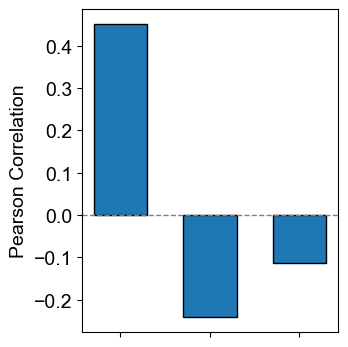

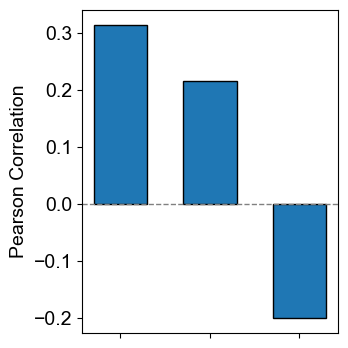

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------- Global font settings (Arial) ---------
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 14,
    "mathtext.default": "regular",      # avoid italic default
})


# Load your exported correlation tables (local paths)
corr_one = pd.read_csv("./corr_one_plane_standardized.csv")
corr_spd = pd.read_csv("./corr_growth_rate_one_plane_standardized.csv")

# --------- Label mapping (suffix style) ---------
suffix_map = {
    "Zr": "metal_cluster",
    "FA": "capping_agent",
    "L": "ligand",
}

def math_label(f):
    suf = suffix_map.get(f, None)
    if suf is None:
        return f
    suf = suf.replace("_", r"\_")
    # c is upright, and the subscript is upright too
    return rf"$\mathrm{{c}}_{{\mathrm{{{suf}}}}}$"


# ------------------------------------------
# Bar plot 1: one-plane (only FA, L, Zr)
# ------------------------------------------
features_1 = ["FA", "L", "Zr"]
sub1 = corr_one.set_index("factor").loc[features_1].reset_index()
r1 = sub1["pearson_r (z vs one_plane)"].values
labels_1 = [math_label(f) for f in features_1]

plt.figure(figsize=(3.7,3.7))
x = np.arange(len(features_1))
plt.bar(x, r1, width= 0.6, edgecolor = 'black', linewidth=1)
plt.axhline(0, linewidth=1, color = 'gray', linestyle='--')
plt.xticks(x, [], rotation=0)
plt.ylabel("Pearson Correlation")
plt.tight_layout()
plt.show()

# ------------------------------------------
# Bar plot 2: growth rate (only Zr, L, FA)
#   log_rate = log(min(a,b)/growth_time)
# ------------------------------------------
features_2 = ["Zr", "L", "FA"]
sub2 = corr_spd.set_index("factor").loc[features_2].reset_index()
r2 = sub2["pearson_r (z vs log_rate)"].values

labels_2 = [math_label(f) for f in features_2]

plt.figure(figsize=(3.7,3.7))
x = np.arange(len(features_2))
plt.bar(x, r2, width= 0.6, edgecolor = 'black', linewidth=1)

plt.axhline(0, linewidth=1, color = 'gray', linestyle='--')
plt.xticks(x, [], rotation=0)
plt.ylabel("Pearson Correlation")
plt.tight_layout()
plt.show()